# Analisis Profitabilitas per Sub-Category (Central - Furniture)

## Metodologi

1. Memfilter data untuk category Furniture di region Central.
2. Menghitung `profit_margin` untuk masing-masing sub-category.
3. Memvisualisasikan hasil perhitungan.

## Persiapan Data dan Library

Mengimpor library yang dibutuhkan dan memuat dataset untuk proses analisis.

In [1]:
# Mengimpor library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore', category=FutureWarning)

# Memuat data
df = pd.read_csv('superstore.csv')
df['order_date'] = pd.to_datetime(df['order_date'], yearfirst=True, errors='coerce')
df['ship_date'] = pd.to_datetime(df['ship_date'], yearfirst=True, errors='coerce')

## Filter Data Furniture di Region Central

Memfilter data untuk category Furniture di region Central sebagai fokus analisis.

In [2]:
df_central_furniture = df[(df['region'] == 'Central') & (df['category'] == 'Furniture')].copy()

## Hitung Profit Margin per Sub-Category

Mengelompokkan data (`df_central_furniture`) berdasarkan sub-category untuk menghitung `profit_margin`.

In [3]:
# Menghitung total sales dan profit untuk masing-masing sub-category
df_agg = df_central_furniture.groupby('sub_category').agg(sales=('sales', 'sum'), profit=('profit', 'sum'))

# Menghitung profit margin
df_agg['profit_margin'] = df_agg['profit'].div(df_agg['sales']).mul(100)

df_agg

,sales,profit,profit_margin
sub_category,,,
Bookcases,24157.1768,-1997.9043,-8.270438
Chairs,85230.6460,6592.7221,7.735154
Furnishings,15254.3700,-3906.2168,-25.607198
Tables,39154.9710,-3559.6504,-9.091184


## Visualisasi Profit Margin per Sub-Category

Memvisualisasikan hasil perhitungan dalam bentuk bar chart untuk mengidentifikasi sub-category yang merugi.

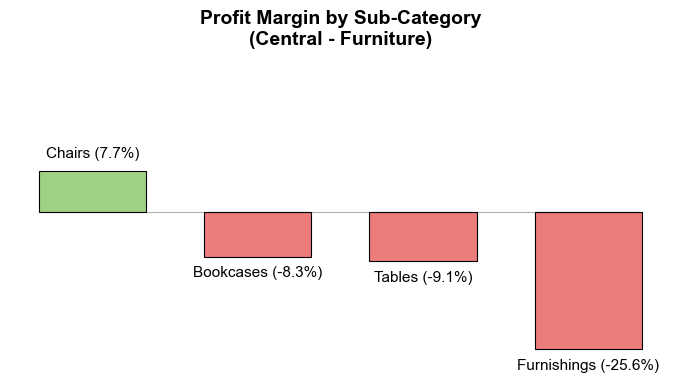

In [4]:
sns.set_theme(style='white')
plt.figure(figsize=(7, 4))
df_agg.sort_values(by='profit_margin', ascending=False, inplace=True)
palette = ['#9ADE7B' if margin > 0 else '#FF6868' for margin in df_agg['profit_margin']]

fig = sns.barplot(x=df_agg.index, y=df_agg['profit_margin'], palette=palette, ec='black', ls='-', lw=0.8)

for bar in fig.patches:
    bar.set_width(0.65)
    bar.set_xy((bar.get_xy()[0] + 0.075, 0))

title_dict = {'size':14,
              'weight':'bold',
              'color':'black',
              'loc':'center',
              'rotation':0,
              'pad':5,
              'alpha':1,
              'family':plt.rcParams['font.family']}    

plt.title('Profit Margin by Sub-Category\n(Central - Furniture)', **title_dict)
plt.xlabel('')
plt.ylabel('')

ax = plt.gca()
ax.set_ylim(-30, 30)
ax.set_xticks(ticks=[])
ax.set_yticks(ticks=[])
ax.axhline(y=0, xmin=0.049, xmax=0.951, color='black', ls='-', lw=0.8, alpha=0.3)

container = ax.containers[0]
labels = [f'{sub_category} ({margin:.1f}%)' for sub_category, margin in zip(df_agg.index, df_agg['profit_margin'])]
ax.bar_label(container=container, labels=labels, size=11, weight='normal', color='black', padding=7)

plt.tight_layout()
sns.despine(left=True, bottom=True)
plt.show()